In [11]:
import copy
import pandas as pd
import numpy as np
from tqdm import tqdm
from ray import tune
import matplotlib.pyplot as plt
import pytagi.metric as metric
from pytagi import Normalizer as normalizer
from canari import (
    DataProcess,
    Model,
    ModelAssemble,
    Optimizer,
    plot_data,
    plot_prediction,
    plot_states,
)
from canari.component import LocalTrend, LstmNetwork, WhiteNoise

In [12]:
# # Read data
data_file = "/Users/vuongdai/Desktop/backup_canari/data/icold_2022.csv"
df_raw = pd.read_csv(data_file, delimiter=",", header=0,
                     names=["datetime","cb2","cb3","waterlevel","temp_a","temp_b"],
                     usecols=["datetime","cb3","waterlevel"],
                     index_col="datetime", parse_dates=True)

# Resample
df_raw = df_raw.loc['2000-01-30':'2012-12-31']
df = df_raw.resample("W").last()

# Data pre-processing
output_col = [0]
covar_col = [1]

In [13]:
# 
NUM_EPOCH = 50
TRAIN_SPLIT = 0.85
VAL_SPLIT = 0.05
OUTPUT_COL = [0] # Target

# seed
rng = np.random.default_rng(1)
seed = rng.integers(0, 1000)      
# seed = 1   

In [14]:
def build_data(covar_num_lag):
    df_lagged = DataProcess.add_lagged_columns(df, [0, covar_num_lag])
    data_processor = DataProcess(
        data=df_lagged,
        time_covariates=["week_of_year"],
        train_split=TRAIN_SPLIT,
        validation_split=VAL_SPLIT,
        output_col=output_col,
    )
    num_features = covar_num_lag + 3

    return data_processor, num_features

In [15]:
# data_processor, num_features = build_data(2)
# data_processor.data.head()

In [16]:
def model_with_parameters(param):
    (
        data_processor,
        num_features,
    ) = build_data(param["covar_num_lag"])

    train_data, validation_data, test_data, _ = data_processor.get_splits()

    # Target model
    model_target = Model(
        LstmNetwork(
            # look_back_len=param["target_look_back_len"],
            look_back_len=1,
            num_features=num_features,
            num_layer=1,
            num_hidden_unit=50,
            manual_seed=seed,
            smoother=False,
        ),
        WhiteNoise(std_error=param["target_sigma_v"]),
    )

    # Covariate model
    model_covar = Model(
        LstmNetwork(
            look_back_len=param["covar_look_back_len"],
            num_features=2,
            num_layer=1,
            num_hidden_unit=50,
            manual_seed=seed,
            smoother=False,
        ),
        WhiteNoise(std_error=param["covar_sigma_v"]),
    )
    model_covar.output_col = covar_col.copy()
    model_covar.input_col = [num_features-1]

    # Assemble models
    model = ModelAssemble(target_model=model_target, covariate_model=model_covar)

    # 
    validation_obs = data_processor.get_data("validation").flatten()

    mu_validation_preds_optim = None
    std_validation_preds_optim = None
    mu_covar_validation_preds_optim = None
    std_covar_validation_preds_optim = None
    mu_test_preds_optim = None
    std_test_preds_optim = None
    mu_covar_test_preds_optim = None
    std_covar_test_preds_optim = None
    num_test = len(test_data["y"])
    num_val = len(validation_data["y"])
    
    for epoch in range(NUM_EPOCH):
        (mu_validation_preds, std_validation_preds) = model.lstm_train(
            train_data=train_data,
            validation_data=validation_data,
        )

        # Validation
        # Tartget predictions
        mu_validation_preds = normalizer.unstandardize(
            mu_validation_preds,
            data_processor.scale_const_mean[output_col],
            data_processor.scale_const_std[output_col],
        )
        std_validation_preds = normalizer.unstandardize_std(
            std_validation_preds,
            data_processor.scale_const_std[output_col],
        )

        mse = metric.mse(mu_validation_preds, validation_obs)
        validation_log_lik = metric.log_likelihood(
            prediction=mu_validation_preds,
            observation=validation_obs,
            std=std_validation_preds,
        )
        
        # Covariate predictions
        mu_covar_validation_preds = np.array(
            model.covariate_model[0].output_history.mu[-num_val:]
        )
        std_covar_validation_preds = (
            np.array(model.covariate_model[0].output_history.var[-num_val:])
            + model.covariate_model[0].sched_sigma_v**2
        ) ** 0.5
        mu_covar_validation_preds = normalizer.unstandardize(
            mu_covar_validation_preds,
            data_processor.scale_const_mean[covar_col],
            data_processor.scale_const_std[covar_col],
        )
        std_covar_validation_preds = normalizer.unstandardize_std(
            std_covar_validation_preds,
            data_processor.scale_const_std[covar_col],
        )

        # Test set
        model.covariate_model[0].set_memory(time_step=data_processor.test_start - 1)
        model.target_model.set_memory(time_step=data_processor.test_start - 1)

        # Tartget predictions
        mu_test_preds, std_test_preds = model.forecast(data=test_data)
        
        mu_test_preds = normalizer.unstandardize(
            mu_test_preds,
            data_processor.scale_const_mean[output_col],
            data_processor.scale_const_std[output_col],
        )
        std_test_preds = normalizer.unstandardize_std(
            std_test_preds,
            data_processor.scale_const_std[output_col],
        )

        # Covariate predictions
        mu_covar_test_preds = np.array(
            model.covariate_model[0].output_history.mu[-num_test:]
        )
        std_covar_test_preds = (
            np.array(model.covariate_model[0].output_history.var[-num_test:]) + model.covariate_model[0].sched_sigma_v**2
        ) ** 0.5
        mu_covar_test_preds = normalizer.unstandardize(
            mu_covar_test_preds,
            data_processor.scale_const_mean[covar_col],
            data_processor.scale_const_std[covar_col],
        )
        std_covar_test_preds = normalizer.unstandardize_std(
            std_covar_test_preds,
            data_processor.scale_const_std[covar_col],
        )

        # Early-stopping on the validation set
        model.target_model.early_stopping(
            evaluate_metric=mse,
            current_epoch=epoch,
            max_epoch=NUM_EPOCH,
            # skip_epoch=5,
        )

        model.covariate_model[0].set_memory(time_step=0)
        model.target_model.set_memory(time_step=0)

        # Metric used by the Optimizer (minimized)
        model.metric_optim = model.target_model.early_stop_metric

        if epoch == model.target_model.optimal_epoch:
            mu_validation_preds_optim = mu_validation_preds
            std_validation_preds_optim = std_validation_preds
            mu_covar_validation_preds_optim = mu_covar_validation_preds
            std_covar_validation_preds_optim = std_covar_validation_preds
            mu_test_preds_optim = mu_test_preds
            std_test_preds_optim = std_test_preds
            mu_covar_test_preds_optim = mu_covar_test_preds
            std_covar_test_preds_optim = std_covar_test_preds

        
        if model.target_model.stop_training:
            break

    return (
        model,
        data_processor,
        mu_validation_preds_optim,
        std_validation_preds_optim,
        mu_covar_validation_preds_optim,
        std_covar_validation_preds_optim,
        mu_test_preds_optim,
        std_test_preds_optim,
        mu_covar_test_preds_optim,
        std_covar_test_preds_optim,
        )


In [17]:
# # Hyperparameter optimization with TPE sampling
param_space = {
    "target_sigma_v": tune.loguniform(1e-2, 2e-1),
    "covar_look_back_len": [10, 62],
    "covar_sigma_v": tune.loguniform(1e-2, 2e-1),
    "covar_num_lag": [0, 26], 
}

model_optimizer = Optimizer(
    model=model_with_parameters,
    param=param_space,
    num_optimization_trial=120,
    num_startup_trials=60,
    mode="min",
    max_concurrent=6,
)
model_optimizer.optimize()

#   1/120 - Metric: 3.568 - Parameter: {'target_sigma_v': 0.04303076462273015, 'covar_look_back_len': 45, 'covar_sigma_v': 0.05874379919966727, 'covar_num_lag': 12}
#   2/120 - Metric: 3.309 - Parameter: {'target_sigma_v': 0.013083203977465837, 'covar_look_back_len': 49, 'covar_sigma_v': 0.010923041280784418, 'covar_num_lag': 12}
#   3/120 - Metric: 1.631 - Parameter: {'target_sigma_v': 0.08845364942172781, 'covar_look_back_len': 61, 'covar_sigma_v': 0.18989061592302953, 'covar_num_lag': 6}
#   4/120 - Metric: 2.687 - Parameter: {'target_sigma_v': 0.03758018813287232, 'covar_look_back_len': 54, 'covar_sigma_v': 0.012719004367417257, 'covar_num_lag': 9}
#   5/120 - Metric: 0.894 - Parameter: {'target_sigma_v': 0.03037056991340568, 'covar_look_back_len': 39, 'covar_sigma_v': 0.04406304158879251, 'covar_num_lag': 12}
#   6/120 - Metric: 3.117 - Parameter: {'target_sigma_v': 0.10881736018058191, 'covar_look_back_len': 58, 'covar_sigma_v': 0.14258171548641088, 'covar_num_lag': 21}
#   7/120

(objective pid=32965) Exception ignored in: <function WeakSet.__init__.<locals>._remove at 0x1019dccc0>
(objective pid=32965) Traceback (most recent call last):
(objective pid=32965)   File "/opt/miniconda3/envs/canari/lib/python3.12/_weakrefset.py", line 39, in _remove
(objective pid=32965)     def _remove(item, selfref=ref(self)):
(objective pid=32965) 
(objective pid=32965)   File "/opt/miniconda3/envs/canari/lib/python3.12/site-packages/ray/_private/worker.py", line 1060, in sigterm_handler
(objective pid=32965)     raise_sys_exit_with_custom_error_message(
(objective pid=32965)   File "python/ray/_raylet.pyx", line 736, in ray._raylet.raise_sys_exit_with_custom_error_message
(objective pid=32965) SystemExit: 1


# 106/120 - Metric: 0.228 - Parameter: {'target_sigma_v': 0.03650217101781152, 'covar_look_back_len': 19, 'covar_sigma_v': 0.024574984272800814, 'covar_num_lag': 16}
# 107/120 - Metric: 0.303 - Parameter: {'target_sigma_v': 0.03470026480986728, 'covar_look_back_len': 20, 'covar_sigma_v': 0.021072580641012067, 'covar_num_lag': 20}
# 108/120 - Metric: 0.280 - Parameter: {'target_sigma_v': 0.03125238514975415, 'covar_look_back_len': 12, 'covar_sigma_v': 0.02576466306832959, 'covar_num_lag': 19}
# 109/120 - Metric: 0.213 - Parameter: {'target_sigma_v': 0.0719091967294421, 'covar_look_back_len': 19, 'covar_sigma_v': 0.02025874524738821, 'covar_num_lag': 24}
# 110/120 - Metric: 0.280 - Parameter: {'target_sigma_v': 0.04477865149637967, 'covar_look_back_len': 20, 'covar_sigma_v': 0.03129772716146712, 'covar_num_lag': 20}
# 111/120 - Metric: 0.310 - Parameter: {'target_sigma_v': 0.07320289739180824, 'covar_look_back_len': 19, 'covar_sigma_v': 0.02492812161477366, 'covar_num_lag': 19}
# 112/120

2026-09-23 10:13:49,348	INFO tune.py:1007 -- Wrote the latest version of all result files and experiment state to '/Users/vuongdai/ray_results/objective_2026-09-23_10-06-38' in 0.0407s.


# 120/120 - Metric: 1.169 - Parameter: {'target_sigma_v': 0.04719749640603404, 'covar_look_back_len': 16, 'covar_sigma_v': 0.023537033176464193, 'covar_num_lag': 21}
-----
Optimal parameters at trial #38. Best metric: 0.0550. Best print metric: None. Best param: {'target_sigma_v': 0.020589202956079453, 'covar_look_back_len': 26, 'covar_sigma_v': 0.13260635343773935, 'covar_num_lag': 15}.
-----


In [18]:
param_optim = model_optimizer.get_best_param()

In [19]:
(   
    model,
    data_processor,
    mu_validation_preds_optim,
    std_validation_preds_optim,
    mu_covar_validation_preds_optim,
    std_covar_validation_preds_optim,
    mu_test_preds_optim,
    std_test_preds_optim,
    mu_covar_test_preds_optim,
    std_covar_test_preds_optim,
) = model_with_parameters(param_optim)

Seed            : 473
Optimal parameters            : {'target_sigma_v': 0.020589202956079453, 'covar_look_back_len': 26, 'covar_sigma_v': 0.13260635343773935, 'covar_num_lag': 15}


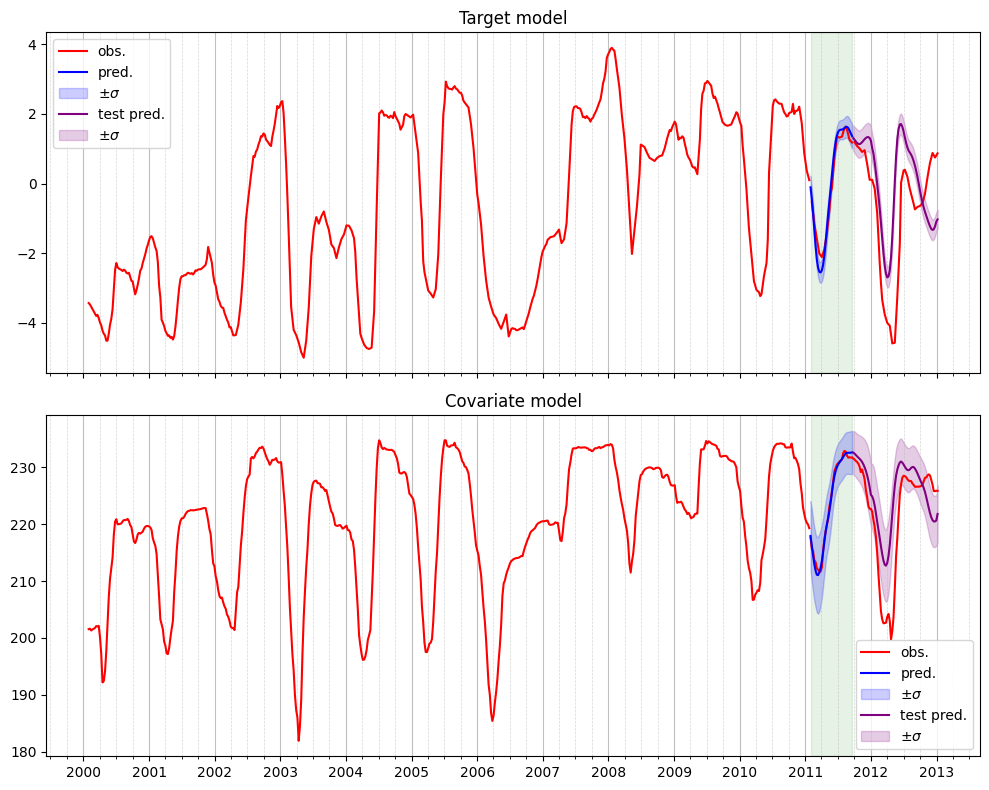

In [20]:

print(f"Seed            : {seed}")
print(f"Optimal parameters            : {param_optim}")

#  Plot
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Target model
plot_data(
    data_processor=data_processor,
    standardization=False,
    plot_column=output_col,
    sub_plot=axs[0],
    plot_nan=False,
    validation_label="obs.",
)
plot_prediction(
    data_processor=data_processor,
    mean_validation_pred=mu_validation_preds_optim,
    std_validation_pred=std_validation_preds_optim,
    sub_plot=axs[0],
    validation_label=["pred.", "$\\pm\\sigma$"],
    num_std = 2,
)
plot_prediction(
    data_processor=data_processor,
    mean_test_pred=mu_test_preds_optim,
    std_test_pred=std_test_preds_optim,
    sub_plot=axs[0],
    test_label=["test pred.", "$\\pm\\sigma$"],
    color="purple",
    num_std = 2,
)
axs[0].set_title("Target model")
axs[0].legend()

# Covariate model
plot_data(
    data_processor=data_processor,
    standardization=False,
    plot_column=covar_col,
    sub_plot=axs[1],
    plot_nan=False,
    validation_label="obs.",
)
plot_prediction(
    data_processor=data_processor,
    mean_validation_pred=mu_covar_validation_preds_optim,
    std_validation_pred=std_covar_validation_preds_optim,
    sub_plot=axs[1],
    validation_label=["pred.", "$\\pm\\sigma$"],
    num_std = 2,
)
plot_prediction(
    data_processor=data_processor,
    mean_test_pred=mu_covar_test_preds_optim,
    std_test_pred=std_covar_test_preds_optim,
    sub_plot=axs[1],
    test_label=["test pred.", "$\\pm\\sigma$"],
    color="purple",
    num_std = 2,
)
axs[1].set_title("Covariate model")
axs[1].legend()

plt.tight_layout()
plt.show()